### STEP 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import resample

import warnings
warnings.filterwarnings("ignore")

ModuleNotFoundError: No module named 'matplotlib'

### STEP 2: Load Dataset

In [ ]:
df = pd.read_csv("pcod_menses_dataset.csv")
df.head()

,Age,Height,Weight,Length_of_cycle,Length_of_menses,Number_of_peaks,Unusual_bleeding,Family_history,Menses_score
0,61,5.88,49.6,43,15,2,No,pcod/pcos,1
1,18,5.42,70.1,45,8,1,No,no,1
2,39,5.97,50.2,57,4,3,Yes,diabetics,1
3,17,5.39,77.5,44,2,2,No,no,0
4,33,5.84,36.6,24,13,2,Yes,thyroid,0


### STEP 3: Basic Dataset Inspection

In [ ]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

Dataset Shape: (600, 9)

Missing Values:
 Age                 0
Height              0
Weight              0
Length_of_cycle     0
Length_of_menses    0
Number_of_peaks     0
Unusual_bleeding    0
Family_history      0
Menses_score        0
dtype: int64

Data Types:
 Age                   int64
Height              float64
Weight              float64
Length_of_cycle       int64
Length_of_menses      int64
Number_of_peaks       int64
Unusual_bleeding     object
Family_history       object
Menses_score          int64
dtype: object


### STEP 4: Data Cleaning

##### 4.1 Encode Categorical Variables

In [ ]:
df['Unusual_bleeding'] = df['Unusual_bleeding'].map({'Yes':1, 'No':0})
df['Family_history'] = df['Family_history'].astype('category').cat.codes

df.head()

,Age,Height,Weight,Length_of_cycle,Length_of_menses,Number_of_peaks,Unusual_bleeding,Family_history,Menses_score
0,61,5.88,49.6,43,15,2,0,2,1
1,18,5.42,70.1,45,8,1,0,1,1
2,39,5.97,50.2,57,4,3,1,0,1
3,17,5.39,77.5,44,2,2,0,1,0
4,33,5.84,36.6,24,13,2,1,3,0


### STEP 5: Add Synthetic Data (Balance Dataset)

In [ ]:
# Check Class Distribution
print("Original Class Distribution:\n", df['Menses_score'].value_counts())

Original Class Distribution:
 Menses_score
0    351
1    249
Name: count, dtype: int64


In [ ]:
# Upsampling Minority Class

majority = df[df['Menses_score'] == 0]
minority = df[df['Menses_score'] == 1]

minority_upsampled = resample(minority,
                              replace=True,
                              n_samples=len(majority),
                              random_state=42)

df_balanced = pd.concat([majority, minority_upsampled])

print("Balanced Class Distribution:\n", df_balanced['Menses_score'].value_counts())

Balanced Class Distribution:
 Menses_score
0    351
1    351
Name: count, dtype: int64


### STEP 6: Exploratory Data Analysis (EDA)

##### 6.1 Basic Statistics

In [ ]:
df_balanced.describe()

,Age,Height,Weight,Length_of_cycle,Length_of_menses,Number_of_peaks,Unusual_bleeding,Family_history,Menses_score
count,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000
mean,39.039886,5.508575,63.612393,39.256410,6.591168,2.601140,0.294872,1.390313,0.500000
std,14.761677,0.281542,16.410587,11.533852,3.804357,1.685009,0.456310,0.959266,0.500357
min,14.000000,5.000000,35.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,26.000000,5.280000,49.525000,29.250000,3.000000,1.000000,0.000000,1.000000,0.000000
50%,39.000000,5.490000,64.300000,39.000000,6.000000,3.000000,0.000000,1.000000,0.500000
75%,52.000000,5.750000,78.600000,49.000000,9.000000,4.000000,1.000000,2.000000,1.000000
max,65.000000,6.000000,89.900000,60.000000,15.000000,5.000000,1.000000,3.000000,1.000000


##### 6.2 Correlation Heatmap

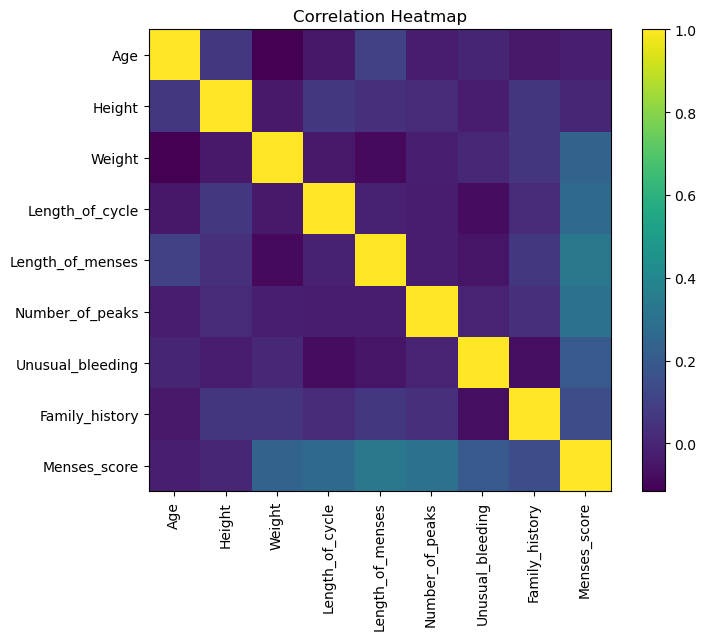

In [ ]:
corr = df_balanced.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

### STEP 7: Remove Weak Features

In [ ]:
# Feature Selection

target_corr = corr['Menses_score'].abs()
weak_features = target_corr[target_corr < 0.05].index.tolist()

if 'Menses_score' in weak_features:
    weak_features.remove('Menses_score')

print("Weak Features:", weak_features)

df_model = df_balanced.drop(columns=weak_features)
df_model.head()

Weak Features: ['Age', 'Height']


,Weight,Length_of_cycle,Length_of_menses,Number_of_peaks,Unusual_bleeding,Family_history,Menses_score
3,77.5,44,2,2,0,1,0
4,36.6,24,13,2,1,3,0
5,64.8,21,2,3,0,1,0
6,60.8,27,5,4,1,1,0
10,45.8,47,6,4,0,1,0


### STEP 8: Train-Test Split

In [ ]:
X = df_model.drop('Menses_score', axis=1)
y = df_model['Menses_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (561, 6)
Testing Shape: (141, 6)


### STEP 9: Feature Scaling (For Logistic Regression)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### STEP 10: Model Building

##### 10.1 Logistic Regression

In [ ]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.7872340425531915
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        76
           1       0.77      0.77      0.77        65

    accuracy                           0.79       141
   macro avg       0.79      0.79      0.79       141
weighted avg       0.79      0.79      0.79       141



##### 10.2 Decision Tree

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.900709219858156
              precision    recall  f1-score   support

           0       0.93      0.88      0.91        76
           1       0.87      0.92      0.90        65

    accuracy                           0.90       141
   macro avg       0.90      0.90      0.90       141
weighted avg       0.90      0.90      0.90       141



##### 10.3 Random Forest

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9716312056737588
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        76
           1       0.97      0.97      0.97        65

    accuracy                           0.97       141
   macro avg       0.97      0.97      0.97       141
weighted avg       0.97      0.97      0.97       141



### STEP 11: Hyperparameter Tuning (Random Forest)

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(),
                    param_grid,
                    cv=5)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_rf = grid.best_estimator_

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


### STEP 12: Cross Validation

In [ ]:
cv_scores = cross_val_score(best_rf, X, y, cv=5)
print("Cross Validation Accuracy:", np.mean(cv_scores))

Cross Validation Accuracy: 0.9657852077001013


### STEP 13: Overfitting Check

In [ ]:
train_acc = best_rf.score(X_train, y_train)
test_acc = best_rf.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 1.0
Testing Accuracy: 0.9716312056737588


### STEP 14: Feature Importance

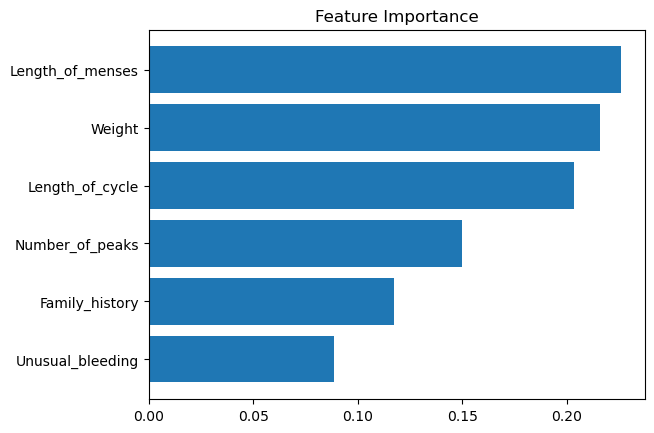

In [ ]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Feature Importance")
plt.show()

### STEP 15: Final Prediction Function

In [ ]:
def predict_pcos(input_data):
    input_array = np.array(input_data).reshape(1, -1)
    prediction = best_rf.predict(input_array)
    
    if prediction[0] == 1:
        return "High Risk of PCOS"
    else:
        return "Low Risk of PCOS"

### STEP 16: Test Prediction

In [ ]:
sample = X.iloc[0].values
predict_pcos(sample)

'Low Risk of PCOS'